In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
DATA_PATH = Path("SMSSpamCollection")

df = pd.read_csv(
    DATA_PATH,
    sep="\t",
    header=None,
    names=["label", "text"]
)

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.shape

(5572, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5572 non-null   str  
 1   text    5572 non-null   str  
dtypes: str(2)
memory usage: 542.9 KB


In [5]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [6]:
df["label"].value_counts(normalize=True)

label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64

In [7]:
df.duplicated().sum()

np.int64(403)

In [8]:
df["text"].duplicated().sum()

np.int64(403)

In [4]:
df[df["text"].duplicated(keep=False)].sort_values("text").head(20)

,label,text
505,spam,+123 Congratulations - in this week's competit...
2124,spam,+123 Congratulations - in this week's competit...
1373,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2163,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2344,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1050,spam,18 days to Euro2004 kickoff! U will be kept in...
2719,spam,18 days to Euro2004 kickoff! U will be kept in...
389,spam,4mths half price Orange line rental & latest c...
2044,spam,4mths half price Orange line rental & latest c...
1470,ham,7 wonders in My WORLD 7th You 6th Ur style 5th...


In [5]:
df.isna().sum()

label    0
text     0
dtype: int64

In [6]:
df = df.dropna(subset=["label", "text"]).copy()

In [12]:
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [13]:
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

In [14]:
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5164,spam,This is the 2nd time we have tried 2 contact u...
5165,ham,Will ü b going to esplanade fr home?
5166,ham,"Pity, * was in mood for that. So...any other s..."
5167,ham,The guy did some bitching but I acted like i'd...


In [15]:
df.iloc[0]["text"]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [13]:
df["label_id"] = (
    df["label"]
    .map({"ham": 0, "spam": 1})
    .astype(int)
)

In [14]:
df

,label,text,char_length,word_length,label_id
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,0
1,ham,Ok lar... Joking wif u oni...,29,6,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1
3,ham,U dun say so early hor... U c already then say...,49,11,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,0
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160,30,1
5568,ham,Will ü b going to esplanade fr home?,36,8,0
5569,ham,"Pity, * was in mood for that. So...any other s...",57,10,0
5570,ham,The guy did some bitching but I acted like i'd...,125,26,0


In [15]:
df.head()

,label,text,char_length,word_length,label_id
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,0
1,ham,Ok lar... Joking wif u oni...,29,6,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1
3,ham,U dun say so early hor... U c already then say...,49,11,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,0


In [16]:
df["char_length"] = df["text"].str.len()
df["word_length"] = df["text"].str.split().str.len()

In [17]:
df

,label,text,char_length,word_length,label_id
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,0
1,ham,Ok lar... Joking wif u oni...,29,6,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1
3,ham,U dun say so early hor... U c already then say...,49,11,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,0
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160,30,1
5568,ham,Will ü b going to esplanade fr home?,36,8,0
5569,ham,"Pity, * was in mood for that. So...any other s...",57,10,0
5570,ham,The guy did some bitching but I acted like i'd...,125,26,0


In [18]:
df.groupby("label")[["char_length", "word_length"]].describe()

char_length                                                           \
            count        mean        std   min    25%    50%    75%    max   
label                                                                        
ham        4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0   
spam        747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0   

      word_length                                                      
            count       mean        std  min   25%   50%   75%    max  
label                                                                  
ham        4825.0  14.310259  11.517945  1.0   7.0  11.0  19.0  171.0  
spam        747.0  23.911647   5.780174  2.0  22.0  25.0  28.0   35.0

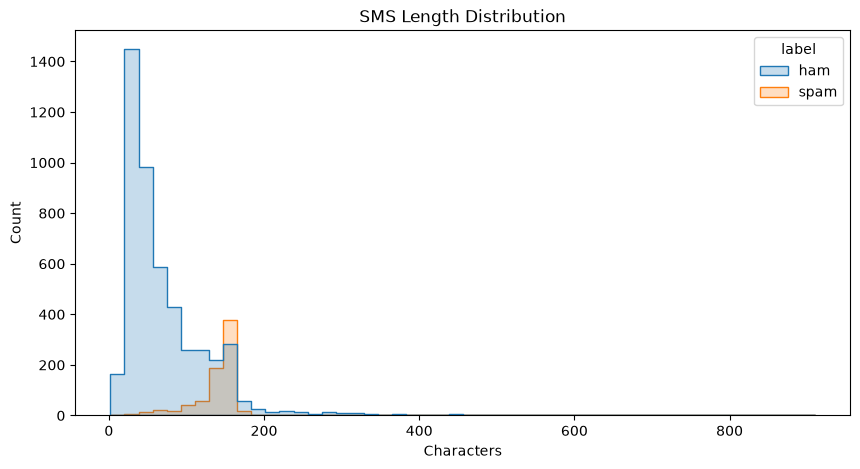

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="char_length",
    hue="label",
    bins=50,
    element="step"
)

plt.title("SMS Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")

plt.show()

In [23]:
df["label_id"]

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: label_id, Length: 5572, dtype: int64

In [24]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label_id"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=42
)

In [30]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 4457
Validation: 557
Test: 558


In [31]:
print("Train distribution")
print(train_df["label"].value_counts(normalize=True))

print("\nValidation distribution")
print(val_df["label"].value_counts(normalize=True))

print("\nTest distribution")
print(test_df["label"].value_counts(normalize=True))

Train distribution
label
ham     0.865829
spam    0.134171
Name: proportion, dtype: float64

Validation distribution
label
ham     0.867145
spam    0.132855
Name: proportion, dtype: float64

Test distribution
label
ham     0.865591
spam    0.134409
Name: proportion, dtype: float64


In [32]:
processed_dir = Path("data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

In [33]:
train_df[["text", "label", "label_id"]].to_csv(
    processed_dir / "train.csv",
    index=False
)

val_df[["text", "label", "label_id"]].to_csv(
    processed_dir / "validation.csv",
    index=False
)

test_df[["text", "label", "label_id"]].to_csv(
    processed_dir / "test.csv",
    index=False
)

In [30]:
list(processed_dir.iterdir())


[PosixPath('../data/processed/validation.csv'),
 PosixPath('../data/processed/train.csv'),
 PosixPath('../data/processed/test.csv')]

In [35]:
train_df["label_id"].mode()[0]


np.int64(0)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

majority_class = train_df["label_id"].mode()[0]

predictions = np.full(
    len(test_df),
    majority_class
)

majority_accuracy = accuracy_score(
    test_df["label_id"],
    predictions
)

majority_f1 = f1_score(
    test_df["label_id"],
    predictions
)

print("Majority class:", majority_class)
print("Accuracy:", majority_accuracy)
print("F1:", majority_f1)

Majority class: 0
Accuracy: 0.8655913978494624
F1: 0.0


In [34]:
df.shape
df["label"].value_counts()
df.duplicated().sum()

print(len(train_df))
print(len(val_df))
print(len(test_df))

print(majority_accuracy)
print(majority_f1)

4135
517
517
0.874274661508704
0.0


In [ ]:
baseline_results = pd.DataFrame({
    "model": ["Majority Class"],
    "majority_class" : [majority_class],
    "accuracy": [majority_accuracy],
    "f1": [majority_f1]
})

baseline_results

,model,majority_class,accuracy,f1
0,Majority Class,0,0.865591,0.0


In [45]:
baseline_results.to_csv("baseline_results.csv", index=True)